# 01: Deep Learning සඳහා EDA සහ Technique Selection Guide
### (Exploratory Data Analysis to Deep Learning Technique Selection Rationale)

මෙම Notebook එකෙහි අරමුණ වන්නේ Deep Learning ව්‍යාපෘතියක් ආරම්භයේදී Dataset එකක් හමුවූ විට, සාර්ථක EDA (Exploratory Data Analysis) ක්‍රියාවලියක් සිදුකර දත්තවල ලක්ෂණ (Data Characteristics) හඳුනාගෙන, ඒ අනුව සුදුසුම DL Architecture, Preprocessing Methods, Loss Functions, Data Augmentation සහ Regularization Techniques තෝරාගන්නා ආකාරය පියවරෙන් පියවර සිංහලෙන්ම උගන්වාදීමයි.

අපි මෙහිදී වෙනස්ම ආකාරයේ Real-world Datasets 3ක් අධ්‍යයනය කරමු:
1. Computer Vision (Image Dataset): Fashion-MNIST / CIFAR-10
2. Natural Language Processing (Text Dataset): Real SMS Spam / IMDB Text Dataset
3. Tabular Data (Structured Dataset): California Housing Dataset


--- 
## 1. Computer Vision (Image Dataset) - EDA සහ Decision Making

රූප (Images) සමඟ වැඩ කිරීමේදී EDA මගින් අපි පහත කරුණු පරීක්ෂා කළ යුතුය:
- Image Shapes & Dimensions: සියලුම පින්තූර එකම ප්‍රමාණයේද? (e.g. 28x28, 224x224)
- Color Channels: Grayscale (1 channel) ද RGB (3 channels) ද?
- Pixel Intensity Values: Pixel අගයන් පවතින්නේ [0, 255] පරාසයේද?
- Class Balance: එක් එක් පංතියට (Class) අයත් පින්තූර ගණන සමානද?
- Image Noise & Quality: පින්තූර පැහැදිලිද, blur වී තිබේද, නියමිත ස්ථානයේ (centered) පවතීද?


In [1]:
# අවශ්‍ය libraries import කිරීම
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

print("TensorFlow Version:", tf.__version__)

# 1. Fashion-MNIST Dataset එක load කිරීම (Directly via Keras Datasets)
(X_train_img, y_train_img), (X_test_img, y_test_img) = tf.keras.datasets.fashion_mnist.load_data()

# Image Class Names
class_names_img = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 
                   'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print("Training Images Shape:", X_train_img.shape)
print("Training Labels Shape:", y_train_img.shape)
print("Test Images Shape:", X_test_img.shape)


TensorFlow Version: 2.21.0
Training Images Shape: (60000, 28, 28)
Training Labels Shape: (60000,)
Test Images Shape: (10000, 28, 28)


Minimum Pixel Value: 0
Maximum Pixel Value: 255
Mean Pixel Value: 72.94
Std Dev Pixel Value: 90.02


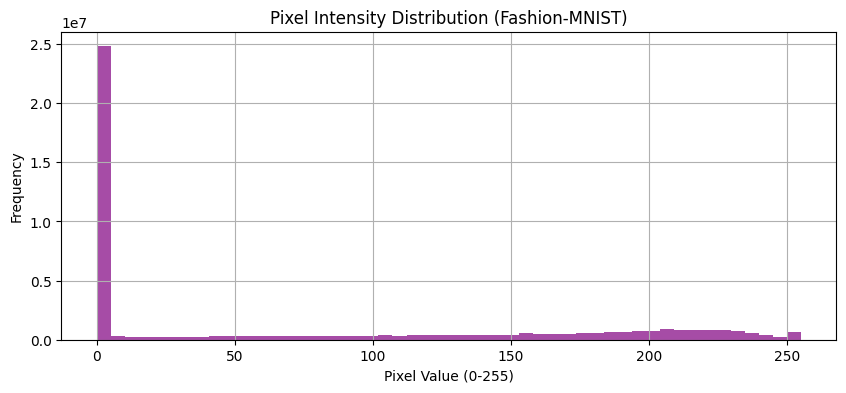

In [2]:
# EDA Step 1.1: Pixel Intensity Distribution පරීක්ෂා කිරීම
print(f"Minimum Pixel Value: {X_train_img.min()}")
print(f"Maximum Pixel Value: {X_train_img.max()}")
print(f"Mean Pixel Value: {X_train_img.mean():.2f}")
print(f"Std Dev Pixel Value: {X_train_img.std():.2f}")

plt.figure(figsize=(10, 4))
plt.hist(X_train_img.ravel(), bins=50, color='purple', alpha=0.7)
plt.title("Pixel Intensity Distribution (Fashion-MNIST)")
plt.xlabel("Pixel Value (0-255)")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()


### Plot 1 Detailed Explanation: Pixel Intensity Distribution
- **ප්‍රස්ථාරයේ ස්වභාවය:** Histogram (පික්සල් අගයන්හි ව්‍යාප්තිය).
- **X-අක්ෂය (X-axis):** Pixel Intensity අගයන් (0 සිට 255 දක්වා). 0 යනු සම්පූර්ණ කළු (Black / Background) වන අතර 255 යනු සම්පූර්ණ සුදු (White / Foreground) වේ.
- **Y-අක්ෂය (Y-axis):** Frequency (එම අගයට අයත් pixels ගණන).
- **නිරීක්ෂණය (Insight):** 0 අගය අසල ඉහළ සංඛ්‍යාතයක් ඇත (Background). Pixel අගයන් 0-255 පරාසයේ පැවතීම නිසා Gradient Descent අස්ථාවර විය හැක.
- **තෝරාගත් Technique එක:** `tf.keras.layers.Rescaling(1./255)` - Pixel අගයන් [0, 1] පරාසයට පත්කිරීම.

#### විකල්ප Options සහ ඒවා තෝරාගන්නා අවස්ථා (Alternatives & When to Use):
1. **`Rescaling(1./255)` (තෝරාගත් ක්‍රමය):** Pixel අගයන් [0, 1] පරාසයට පත්කරයි. standard image datasets (e.g., MNIST, CIFAR) සඳහා සුදුසුය.
2. **`Rescaling(scale=1./127.5, offset=-1)`:** Pixel අගයන් [-1, 1] පරාසයට පත්කරයි. MobileNet, InceptionV3, GANs වැනි architectures භාවිත කරන විට යොදාගනී.
3. **`Normalization(mean, variance)` (Standardization):** Image channels හි mean=0 සහ std=1 වන සේ සකසයි. ResNet, VGG වැනි Pretrained Models ImageNet weights සමඟ Transfer Learning සඳහා භාවිත කරන විට යොදාගනී.

#### නිල Documentation Links:
- Keras Rescaling Layer: https://www.tensorflow.org/api_docs/python/tf/keras/layers/Rescaling
- Keras Normalization Layer: https://www.tensorflow.org/api_docs/python/tf/keras/layers/Normalization


/var/folders/bb/bm9vglnn4tqcww_nvshb7c4h0000gn/T/ipykernel_7855/1998231933.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[class_names_img[i] for i in unique_classes], y=counts, palette="viridis")


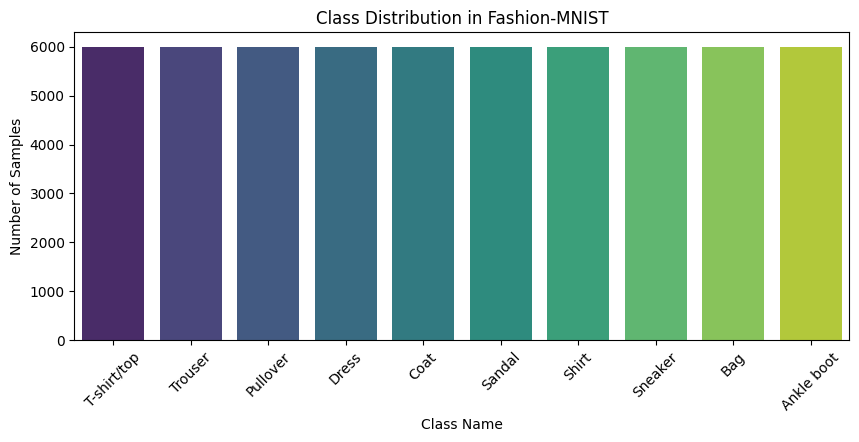

Class 'T-shirt/top': 6000 samples
Class 'Trouser': 6000 samples
Class 'Pullover': 6000 samples
Class 'Dress': 6000 samples
Class 'Coat': 6000 samples
Class 'Sandal': 6000 samples
Class 'Shirt': 6000 samples
Class 'Sneaker': 6000 samples
Class 'Bag': 6000 samples
Class 'Ankle boot': 6000 samples


In [3]:
# EDA Step 1.2: Class Balance (පංති බෙදී පැවතීම) පරීක්ෂා කිරීම
unique_classes, counts = np.unique(y_train_img, return_counts=True)

plt.figure(figsize=(10, 4))
sns.barplot(x=[class_names_img[i] for i in unique_classes], y=counts, palette="viridis")
plt.title("Class Distribution in Fashion-MNIST")
plt.xlabel("Class Name")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45)
plt.show()

for idx, count in zip(unique_classes, counts):
    print(f"Class '{class_names_img[idx]}': {count} samples")


### Plot 2 Detailed Explanation: Class Distribution Bar Plot
- **ප්‍රස්ථාරයේ ස්වභාවය:** Bar Chart (පංති බෙදී පැවතීම).
- **X-අක්ෂය:** Fashion-MNIST හි ඇඳුම් සහ පාවහන් වර්ග 10 (Classes).
- **Y-අක්ෂය:** Number of Samples (සෑම පංතියකටම අයත් රූප සංඛ්‍යාව - 6,000 samples per class).
- **නිරීක්ෂණය:** Perfectly Balanced Dataset එකකි.
- **තෝරාගත් Technique එක:** Standard Categorical Metrics (`Accuracy`) සහ Integer Loss (`SparseCategoricalCrossentropy`).

#### විකල්ප Options සහ ඒවා තෝරාගන්නා අවස්ථා (Alternatives & When to Use):
1. **`SparseCategoricalCrossentropy` (තෝරාගත් ක්‍රමය):** Target labels Integer අගයන් ලෙස (e.g., 0, 1, 2, ..., 9) පවතින විට භාවිත කරයි. Memory ඉතිරි වේ.
2. **`CategoricalCrossentropy`:** Target labels One-Hot Encoded vectors ලෙස (e.g., [1, 0, 0, ...]) පවතින විට භාවිත කරයි.
3. **`Focal Loss` / `Weighted Crossentropy`:** Dataset එකෙහි Class Imbalance පවතින විට (e.g., 90% vs 10%), සුළුතර class එකෙහි නිවැරදි බවට වැඩි බර තැබීමට යොදාගනී.

#### නිල Documentation Links:
- Keras Losses: https://www.tensorflow.org/api_docs/python/tf/keras/losses
- SparseCategoricalCrossentropy: https://www.tensorflow.org/api_docs/python/tf/keras/losses/SparseCategoricalCrossentropy


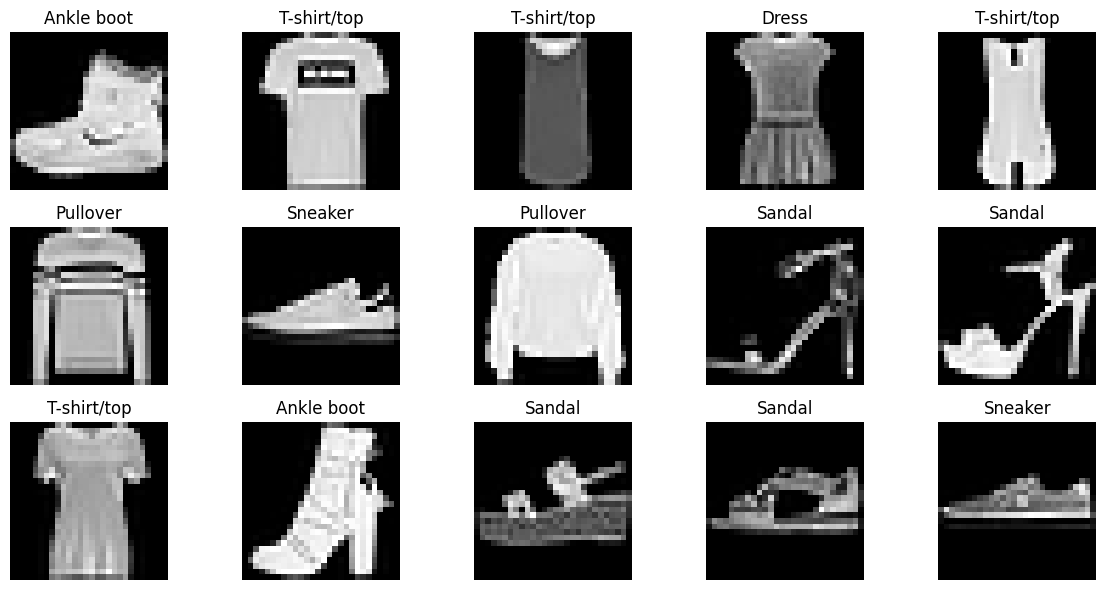

In [4]:
# EDA Step 1.3: Sample Images Visualization
plt.figure(figsize=(12, 6))
for i in range(15):
    plt.subplot(3, 5, i + 1)
    plt.imshow(X_train_img[i], cmap='gray')
    plt.title(class_names_img[y_train_img[i]])
    plt.axis('off')
plt.tight_layout()
plt.show()


### Plot 3 Detailed Explanation: Sample Image Grid & Architecture Options
- **ප්‍රස්ථාරයේ ස්වභාවය:** Image Grid (sample grayscale images 15ක්).
- **නිරීක්ෂණය:** 28x28 Grayscale images; ඇඳුම් අතර සූක්ෂ්ම වෙනස්කම් පවතී.
- **තෝරාගත් Architecture & Augmentation:** `Conv2D` + `MaxPooling2D` සහ `RandomFlip("horizontal")`.

#### විකල්ප Architecture & Data Augmentation Options:

**Architecture Options:**
1. **`Conv2D` (Standard CNN - තෝරාගත් ක්‍රමය):** 2D Image Grid වල Spatial Edges/Textures හඳුනා ගැනීමට යොදාගනී.
2. **`SeparableConv2D` (Depthwise Separable Convolution):** Spatial convolution සහ Channelwise convolution වෙන්කර සිදුකරයි. Mobile/Edge devices සඳහා ඉතා පරාමිතීන් අඩු (Lightweight) ආකෘති සෑදීමට (e.g., MobileNet) යොදාගනී.
3. **`Conv3D`:** Video data (Frames over time) හෝ 3D Medical Scans (CT/MRI scans) සඳහා යොදාගනී.

**Data Augmentation Options:**
1. **`RandomFlip("horizontal")` (තෝරාගත් ක්‍රමය):** රූපය තිරස් අතට හැරවීම. ඇඳුම්, වාහන, ස්වාභාවික රූප සඳහා සුදුසුය.
2. **`RandomRotation(factor=0.1)`:** රූපය නිශ්චිත කෝණයකින් කරකැවීම. ඡායාරූප විවිධ කෝණවලින් ලබාගෙන ඇති විට භාවිත කරයි.
3. **`RandomZoom(height_factor=0.2)`:** රූපය ලංකිරීම (Zoom in) හෝ ඈත්කිරීම (Zoom out). වස්තු විවිධ දුරින් පිහිටන විට යොදාගනී.
4. **`RandomCrop` / `ColorJitter`:** ඡායාරූප කපාගැනීම හෝ ආලෝකය/වර්ණ වෙනස් කිරීම. RGB ඡායාරූප අධික ලෙස සංකීර්ණ විට යොදාගනී.

#### නිල Documentation Links:
- Keras Conv2D Layer: https://www.tensorflow.org/api_docs/python/tf/keras/layers/Conv2D
- Keras Image Augmentation Layers: https://www.tensorflow.org/api_docs/python/tf/keras/layers/RandomFlip


--- 
## 2. Natural Language Processing (Text Dataset) - EDA සහ Decision Making


In [5]:
# 2. Real SMS Spam Collection Dataset එක GitHub Public Repository එකකින් Load කිරීම
url_sms = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"
df_sms = pd.read_csv(url_sms, sep='\t', header=None, names=['label', 'message'])

print("Dataset Shape:", df_sms.shape)
print(df_sms.head())


Dataset Shape: (5572, 2)
  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...


/var/folders/bb/bm9vglnn4tqcww_nvshb7c4h0000gn/T/ipykernel_7855/2256535944.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_sms, x='label', palette='Set2')


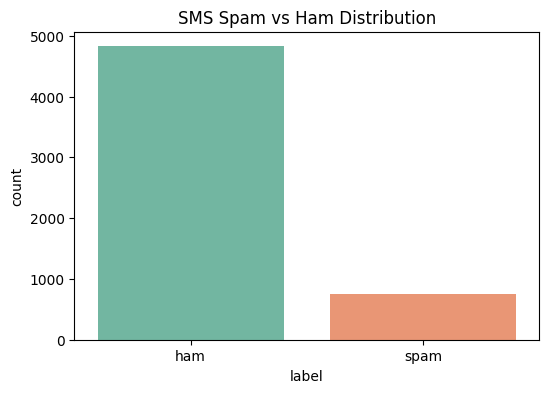

label
ham     86.593683
spam    13.406317
Name: proportion, dtype: float64


In [6]:
# EDA Step 2.1: Target Class Imbalance පරීක්ෂා කිරීම
plt.figure(figsize=(6, 4))
sns.countplot(data=df_sms, x='label', palette='Set2')
plt.title("SMS Spam vs Ham Distribution")
plt.show()

print(df_sms['label'].value_counts(normalize=True) * 100)


### Plot 4 Detailed Explanation: Target Class Distribution (Spam vs Ham)
- **ප්‍රස්ථාරයේ ස්වභාවය:** Count Plot (Spam සහ Ham පණිවිඩ සංඛ්‍යාව).
- **X-අක්ෂය:** Target Class (ham = 86.6%, spam = 13.4%).
- **Y-අක්ෂය:** Message Count.
- **නිරීක්ෂණය:** Imbalanced Dataset එකකි.
- **තෝරාගත් Metrics & Loss:** Binary Crossentropy, Precision, Recall, F1-Score.

#### විකල්ප Loss & Metrics Options:
1. **`BinaryCrossentropy` (තෝරාගත් ක්‍රමය):** Output classes 2ක් පමණක් පවතින විට (0 හෝ 1) යොදාගනී.
2. **`Precision` & `Recall`:** Precision මගින් Spam ලෙස Predict කළ ඒවායින් සැබවින්ම Spam වූ ප්‍රමාණයද, Recall මගින් සැබෑ Spam පණිවිඩවලින් කොපමණ ප්‍රමාණයක් හඳුනාගත්තාද යන්නද මනිනු ලබයි. Spam detection වලදී Precision ඉතා වැදගත් වේ (Ham පණිවිඩයක් Spam ලෙස වැරදීමෙන් වැළකීමට).
3. **`PR-AUC` (Precision-Recall Area Under Curve):** අසමතුලිත binary datasets සඳහා සුදුසුම single metric එකකි.

#### නිල Documentation Links:
- Keras BinaryCrossentropy: https://www.tensorflow.org/api_docs/python/tf/keras/losses/BinaryCrossentropy
- Keras Metrics: https://www.tensorflow.org/api_docs/python/tf/keras/metrics


/var/folders/bb/bm9vglnn4tqcww_nvshb7c4h0000gn/T/ipykernel_7855/500426762.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_sms, x='label', y='word_count', ax=axes[1], palette='magma')


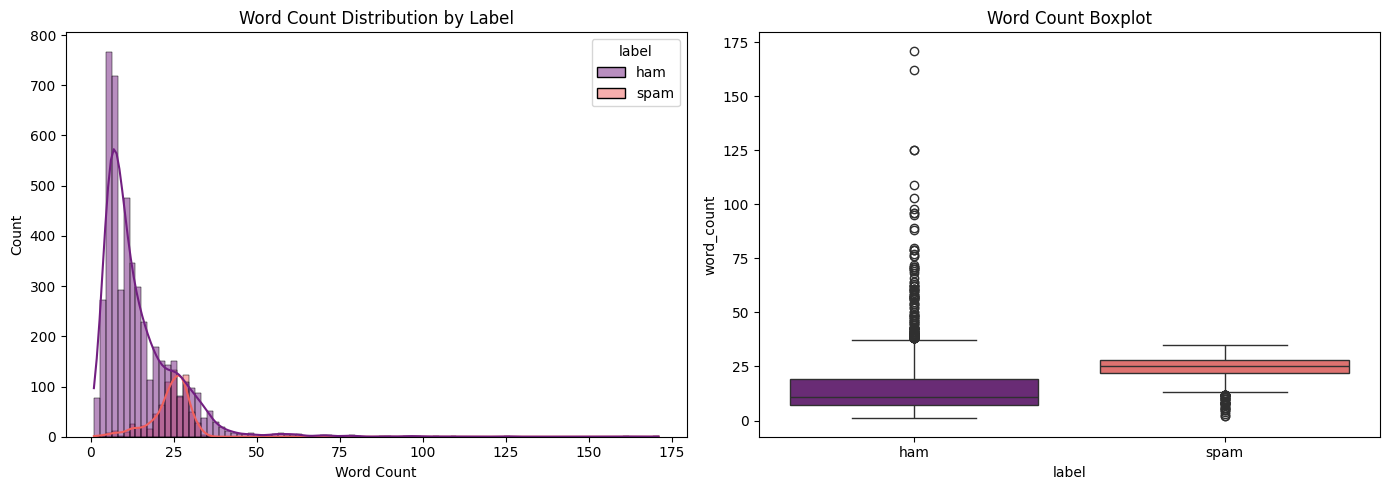

95th Percentile Word Count: 33.0
Max Word Count: 171


In [7]:
# EDA Step 2.2: Sequence Length (Character & Word Count) Distribution
df_sms['char_length'] = df_sms['message'].apply(len)
df_sms['word_count'] = df_sms['message'].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df_sms, x='word_count', hue='label', kde=True, ax=axes[0], palette='magma')
axes[0].set_title("Word Count Distribution by Label")
axes[0].set_xlabel("Word Count")

sns.boxplot(data=df_sms, x='label', y='word_count', ax=axes[1], palette='magma')
axes[1].set_title("Word Count Boxplot")

plt.tight_layout()
plt.show()

print("95th Percentile Word Count:", np.percentile(df_sms['word_count'], 95))
print("Max Word Count:", df_sms['word_count'].max())


### Plot 5 Detailed Explanation: Word Count Distribution & Sequence Modeling Options
- **නිරීක්ෂණය:** 95th Percentile Word Count එක 35-40ක් වේ.
- **තෝරාගත් Vectorizer & Architecture:** `TextVectorization(output_sequence_length=50)` + `Embedding` + `Bidirectional(LSTM)`.

#### විකල්ප NLP Architecture & Vectorization Options:

**NLP Architecture Options:**
1. **`Bidirectional(LSTM)` (තෝරාගත් ක්‍රමය):** පෙළෙහි ඉදිරියට සහ ආපසු යන දිශා දෙකටම පවතින Sequential Context එක තේරුම් ගනී. Sentiment Analysis / Text Classification සඳහා ඉතා සාර්ථකයි.
2. **`GRU` (Gated Recurrent Unit):** LSTM වලට වඩා පරාමිතීන් (Gates) අඩු බැවින් ඉතා වේගවත්ය. කුඩා datasets හෝ memory සීමිත පද්ධති සඳහා යොදාගනී.
3. **`Conv1D` (1D Convolutional Net):** N-gram patterns (ලඟින් පිහිටි වචන එකතු) හඳුනා ගැනීමට ඉතා වේගවත්ය. Recurrent layers වලට වඩා ඉතා ඉක්මනින් Train වේ.
4. **`Transformer (MultiHeadAttention)`:** දීර්ඝ ලිපි (Long documents) සහ ඉතා සංකීර්ණ සන්දර්භීය අර්ථයන් (Contextual semantics) සඳහා යොදාගනී (e.g., BERT, GPT).

#### නිල Documentation Links:
- Keras TextVectorization Layer: https://www.tensorflow.org/api_docs/python/tf/keras/layers/TextVectorization
- Keras Embedding Layer: https://www.tensorflow.org/api_docs/python/tf/keras/layers/Embedding
- Keras Recurrent Layers (LSTM/GRU): https://www.tensorflow.org/api_docs/python/tf/keras/layers/LSTM


--- 
## 3. Tabular Data (Structured Dataset) - EDA සහ Decision Making


In [8]:
# 3. California Housing Dataset (Tabular Regression) Load කිරීම
from sklearn.datasets import fetch_california_housing

housing_data = fetch_california_housing(as_frame=True)
df_housing = housing_data.frame

print("Tabular Dataset Shape:", df_housing.shape)
print(df_housing.head())


Tabular Dataset Shape: (20640, 9)
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  


In [9]:
# EDA Step 3.1: Missing Values & Data Types
print("Missing Values Summary:")
print(df_housing.isnull().sum())

print("\nStatistical Summary:")
print(df_housing.describe().T[['mean', 'std', 'min', '50%', 'max']])


Missing Values Summary:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

Statistical Summary:
                    mean          std         min          50%           max
MedInc          3.870671     1.899822    0.499900     3.534800     15.000100
HouseAge       28.639486    12.585558    1.000000    29.000000     52.000000
AveRooms        5.429000     2.474173    0.846154     5.229129    141.909091
AveBedrms       1.096675     0.473911    0.333333     1.048780     34.066667
Population   1425.476744  1132.462122    3.000000  1166.000000  35682.000000
AveOccup        3.070655    10.386050    0.692308     2.818116   1243.333333
Latitude       35.631861     2.135952   32.540000    34.260000     41.950000
Longitude    -119.569704     2.003532 -124.350000  -118.490000   -114.310000
MedHouseVal     2.068558     1.153956    0.149990     1.797000      5.000010


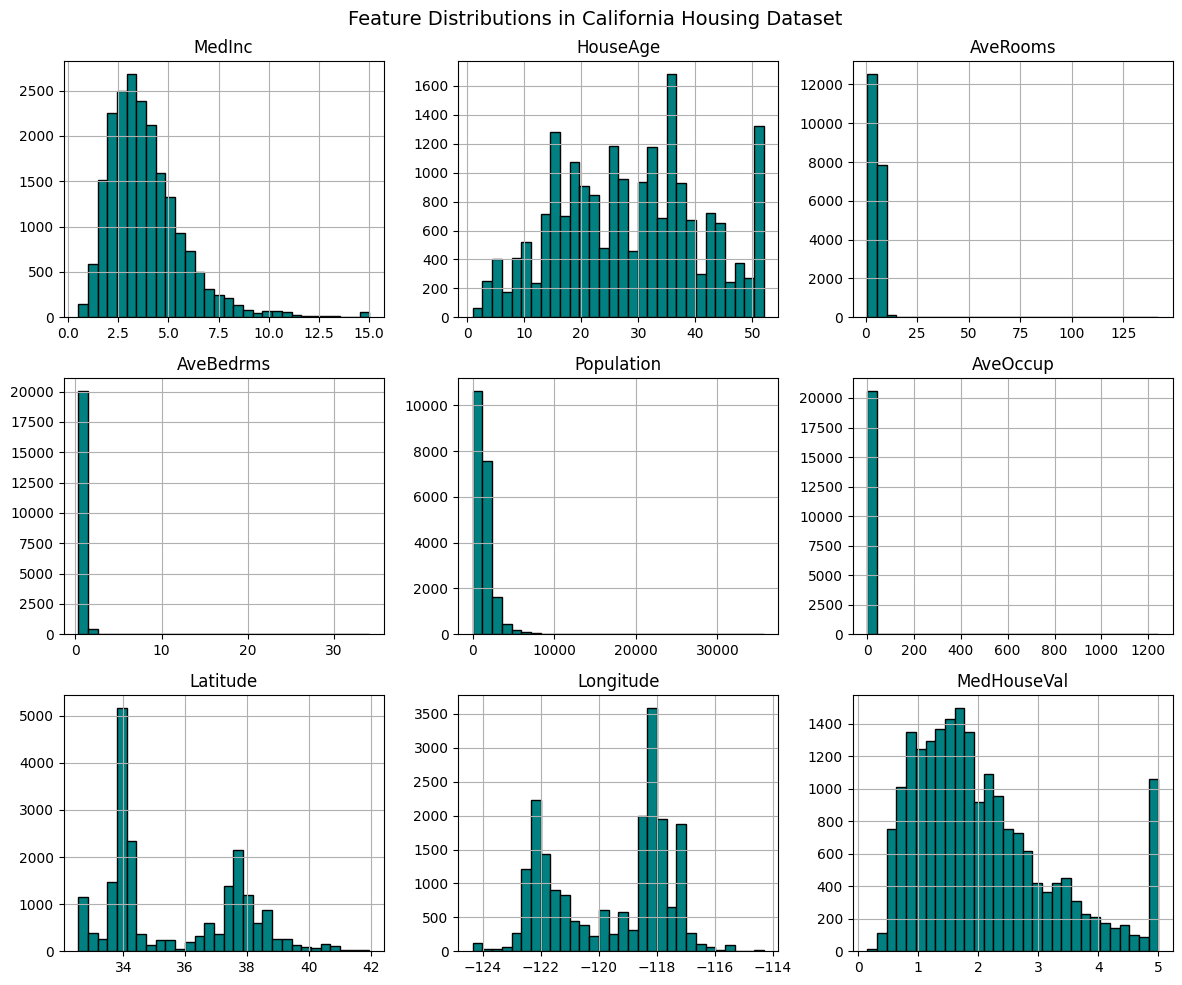

In [10]:
# EDA Step 3.2: Feature Distribution & Skewness Visualizing
df_housing.hist(figsize=(12, 10), bins=30, color='teal', edgecolor='black')
plt.suptitle("Feature Distributions in California Housing Dataset", fontsize=14)
plt.tight_layout()
plt.show()


### Plot 6 Detailed Explanation: Feature Distributions Grid & Scaling Options
- **නිරීක්ෂණය:** Features වල Scales ඉතා වෙනස්ය (0.5-15 vs 3-35000); Right-skewed වී ඇත.
- **තෝරාගත් Technique එක:** `Normalization()` layer (Standardization).

#### විකල්ප Scaling & Loss Options:
1. **`Normalization()` (Standardization - Mean=0, Std=1) (තෝරාගත් ක්‍රමය):** Gaussian distribution එකකට ආසන්න continuous numerical features සඳහා සුදුසුය.
2. **`MinMaxScaler` (Scaling to [0, 1]):** Bounded range එකක් අවශ්‍ය වූ විට භාවිත කරයි.
3. **`Huber Loss` (Loss Option):** Absolute error ($|y - \hat{y}|$) සහ Squared error ($|y - \hat{y}|^2$) දෙකෙහි එකතුවකි. Outliers බහුල tabular datasets සඳහා MSE වලට වඩා සුදුසුය.

#### නිල Documentation Links:
- Keras Normalization Layer: https://www.tensorflow.org/api_docs/python/tf/keras/layers/Normalization
- Keras Huber Loss: https://www.tensorflow.org/api_docs/python/tf/keras/losses/Huber


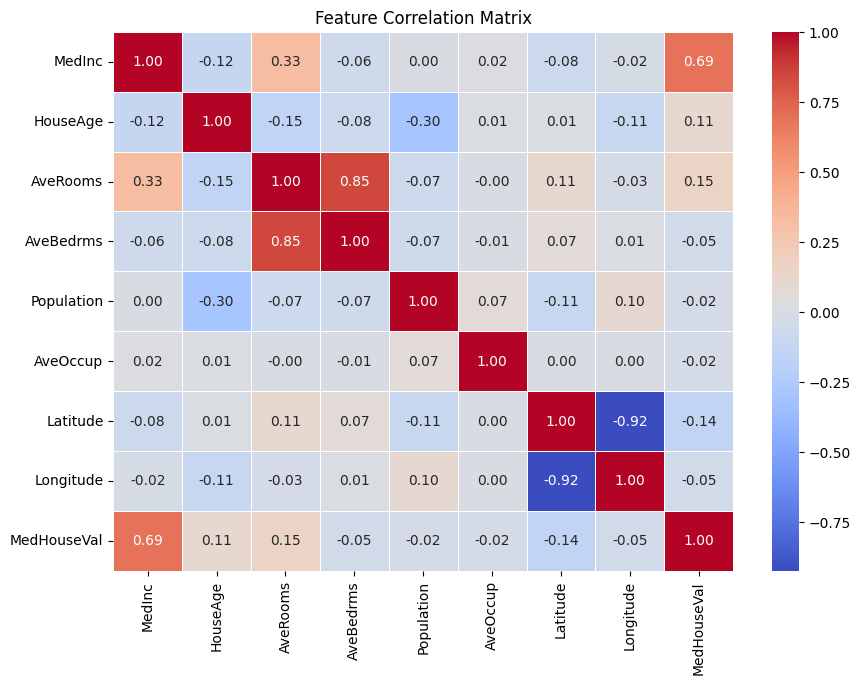

In [11]:
# EDA Step 3.3: Correlation Heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(df_housing.corr(), annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Feature Correlation Matrix")
plt.show()


### Plot 7 Detailed Explanation: Correlation Matrix Heatmap & Regularization Options
- **නිරීක්ෂණය:** Multicollinearity (AveRooms vs AveBedrms = +0.85).
- **තෝරාගත් Technique එක:** Multi-Layer Perceptron (MLP) with `BatchNormalization` & `Dropout`.

#### විකල්ප Regularization & Architecture Options:
1. **`Dropout(rate=0.2)` (තෝරාගත් ක්‍රමය):** Training අතරතුර අහඹු ලෙස Neurons අක්‍රිය කරයි. Overfitting වළක්වයි.
2. **`BatchNormalization()`:** Layers අතර inputs Normalize කරයි. Training වේගවත් කර Gradient Descent ස්ථායී කරයි.
3. **`L2 Regularization (Weight Decay)`:** Weights අධික ලෙස විශාල වීම වැළැක්වීමට loss function එකට penalty එකක් එකතු කරයි.

#### නිල Documentation Links:
- Keras Dropout Layer: https://www.tensorflow.org/api_docs/python/tf/keras/layers/Dropout
- Keras BatchNormalization Layer: https://www.tensorflow.org/api_docs/python/tf/keras/layers/BatchNormalization
